## Project Objective
The goal of this project is to analyze shipment delivery performance,
identify delays (early, on-time, late),
and evaluate their impact on logistics costs.


## Imported Libraries

The following libraries are imported to support data processing, numerical computation, and visualization tasks:

- **`ast`**  
  Enables interaction with Python’s Abstract Syntax Tree (AST), allowing programmatic inspection, analysis, and transformation of Python source code.

- **`pandas (pd)`**  
  Provides high-level data structures and functions for efficient data manipulation, cleaning, and analysis, particularly for tabular datasets.

- **`seaborn (sns)`**  
  A statistical data visualization library built on top of Matplotlib, offering concise syntax and aesthetically enhanced plots.

- **`matplotlib.pyplot (plt)`**  
  A foundational plotting library used to create static, animated, and interactive visualizations.

- **`numpy (np)`**  
  Supports numerical computing through efficient multi-dimensional arrays and a comprehensive set of mathematical functions.


In [1]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

## Data Loading

The dataset is loaded into a Pandas DataFrame using the `read_csv` function:

- **`pd.read_csv()`**  
  Reads a CSV (Comma-Separated Values) file from the specified file path and converts it into a Pandas DataFrame.

- **File Path**  
  The file path points to a local dataset containing supply chain shipment pricing data.

- **`df`**  
  The resulting DataFrame stores the loaded dataset and serves as the primary structure for subsequent data exploration, cleaning, and analysis.

This step initializes the dataset for further analytical and visualization tasks.


In [ ]:
df = pd.read_csv(r'c:\Users\HP\Downloads\Supply_Chain_Shipment_Pricing_Data.csv')
df

,id,project code,pq #,po / so #,asn/dn #,country,managed by,fulfill via,vendor inco term,shipment mode,...,unit of measure (per pack),line item quantity,line item value,pack price,unit price,manufacturing site,first line designation,weight (kilograms),freight cost (usd),line item insurance (usd)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,True,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",True,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,True,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",True,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",True,7590,45450.08,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",False,See DN-4307 (ID#:83920),See DN-4307 (ID#:83920),705.79
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,...,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,False,See DN-4313 (ID#:83921),See DN-4313 (ID#:83921),161.71
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,...,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,False,Weight Captured Separately,Freight Included in Commodity Cost,5284.04
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,True,1392,Freight Included in Commodity Cost,134.03


## Dataset Structure Inspection

The `df.info()` method is used to examine the structure of the dataset, including:

- The total number of records and columns
- Column names
- Non-null value counts
- Data types
- Memory usage

This step helps identify missing values, inappropriate data types, and columns requiring preprocessing.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            10324 non-null  int64  
 1   project code                  10324 non-null  object 
 2   pq #                          10324 non-null  object 
 3   po / so #                     10324 non-null  object 
 4   asn/dn #                      10324 non-null  object 
 5   country                       10324 non-null  object 
 6   managed by                    10324 non-null  object 
 7   fulfill via                   10324 non-null  object 
 8   vendor inco term              10324 non-null  object 
 9   shipment mode                 9964 non-null   object 
 10  pq first sent to client date  10324 non-null  object 
 11  po sent to vendor date        10324 non-null  object 
 12  scheduled delivery date       10324 non-null  object 
 13  d

## Column Selection

A subset of relevant columns is selected to focus the analysis on shipment, vendor, and cost-related attributes.  
Reducing the number of columns improves clarity, performance, and analytical relevance.

The selected columns include:
- Geographic and vendor information
- Shipment and product classification details
- Key shipment dates
- Cost and insurance values

The filtered dataset is reassigned to the DataFrame for further processing.


In [4]:
cols_to_keep = [
    'country', 'vendor', 'shipment mode',
    'product group', 'sub classification',
    'po sent to vendor date', 'scheduled delivery date',
    'delivered to client date',
    'freight cost (usd)', 'line item insurance (usd)'
]

df = df[cols_to_keep]


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    10324 non-null  object 
 1   vendor                     10324 non-null  object 
 2   shipment mode              9964 non-null   object 
 3   product group              10324 non-null  object 
 4   sub classification         10324 non-null  object 
 5   po sent to vendor date     10324 non-null  object 
 6   scheduled delivery date    10324 non-null  object 
 7   delivered to client date   10324 non-null  object 
 8   freight cost (usd)         10324 non-null  object 
 9   line item insurance (usd)  10037 non-null  float64
dtypes: float64(1), object(9)
memory usage: 806.7+ KB


## Date Type Conversion

Certain date-related columns were initially stored as object (string) types.  
These columns are explicitly converted to datetime format using `pd.to_datetime()` to enable accurate date-based calculations and comparisons.

Converted columns:
- `scheduled delivery date`
- `delivered to client date`

This conversion ensures consistency and allows for time-series analysis, delay calculations, and proper sorting.


In [6]:
list_to_date = ['scheduled delivery date', 'delivered to client date']

df = df.copy()                                          # To avoid SettingWithCopyWarning

for col in list_to_date:
    df[col] = pd.to_datetime(df[col], format='mixed')    # mixed format handles different date formats

## Post-Processing Validation

After column selection and data type conversion, `df.info()` is executed again to validate:

- Successful reduction of columns
- Correct datetime data types
- Updated memory usage

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   country                    10324 non-null  object        
 1   vendor                     10324 non-null  object        
 2   shipment mode              9964 non-null   object        
 3   product group              10324 non-null  object        
 4   sub classification         10324 non-null  object        
 5   po sent to vendor date     10324 non-null  object        
 6   scheduled delivery date    10324 non-null  datetime64[ns]
 7   delivered to client date   10324 non-null  datetime64[ns]
 8   freight cost (usd)         10324 non-null  object        
 9   line item insurance (usd)  10037 non-null  float64       
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 806.7+ KB


# To what extent do shipment delays occur ?

### Methodology

- To evaluate shipment delivery performance, the dataset was first cleaned and relevant variables were selected. Scheduled and actual delivery date fields were converted to datetime format to enable accurate date-based calculations.

- Delivery delay was calculated as the difference, in days, between the scheduled delivery date and the actual delivery date. Based on this calculated delay, shipments were classified into three categories: early, on time, and late.

- Frequency analysis was conducted to determine the distribution of delivery delays and delivery status. Visualizations, including bar charts and pie charts, were used to illustrate delay distributions and the proportion of shipments by delivery status.

This methodology provides both quantitative and visual insights into shipment timeliness and overall delivery performance.


### data aggregation

In [8]:
df_delai = df.copy()

In [9]:
df_delai['delay'] = (
    df_delai['scheduled delivery date'] - df_delai['delivered to client date']
    ).dt.days

df_delai



,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36


In [ ]:
df_delai_count = df_delai.value_counts('delay').head(19).to_frame()

df_delai_count

,count
delay,
0,6324
17,127
6,119
8,112
13,107
7,106
2,93
-1,92
19,85


## Results & Visualization

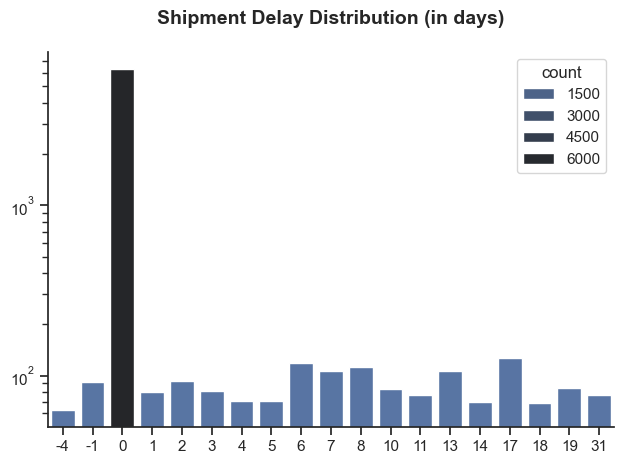

In [11]:
sns.set_theme(style = 'ticks')
sns.barplot(data = df_delai_count,
            x = 'delay',
            y = 'count',           
            hue = 'count',
            palette = 'dark:b_r',
           )
sns.despine()                                        # Remove the top and right spines from plot


plt.yscale("log")
plt.xlabel('')
plt.ylabel('')
plt.title('Shipment Delay Distribution (in days)', pad = 20, fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

Negative delays indicate early deliveries, while positive values represent late deliveries.


**Insight:**  
- Most shipments experience **zero or minimal delay**, indicating generally effective execution.  
- A **small number of shipments incur extended delays**, creating a long tail that disproportionately impacts overall performance.  
- **Targeting the root causes of severe delays** would yield the highest improvement in service reliability.


---

## Shipment Delivery Status Classification


In [12]:
df_delai['shipment delivery'] = np.where(
    df_delai['delay'] < 0 , 'early',                         # if delay < 0 then 'early'
    np.where(                                                # if delay = 0 then 'on time'
        df_delai['delay'] == 0, 'on time',                   # else 'late'
    'late')
)

df_delai

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6,early
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


## Results & Visualization

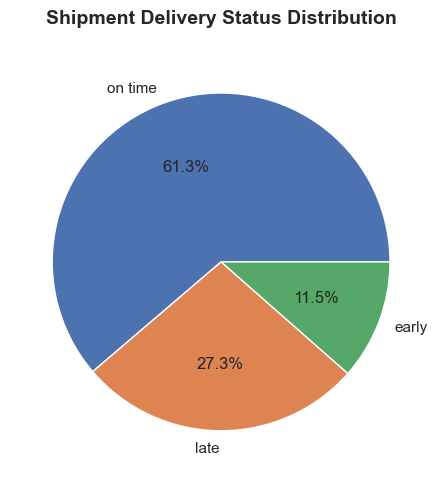

In [13]:
df_delai['shipment delivery'].value_counts().plot(kind = 'pie',
                xlabel = '', 
                ylabel = '',
                figsize = (8,5),
                autopct = '%1.1f%%',                # Show percentages on pie chart
                
                  )

plt.title('Shipment Delivery Status Distribution', pad = 20, fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

**Insight:**  
- A majority of shipments are delivered **on time (61.3%)**, indicating generally stable logistics performance.  
- A **significant 27.3% of shipments are late**, representing a material service gap with cost and customer impact.  
- **Reducing late deliveries** would deliver the greatest improvement in overall service reliability and efficiency.



-----------------------------------------------------------------------------------------------

# Which shipment modes cause the longest delays ?


### Objective
This analysis evaluates delivery performance across different shipment modes by examining the percentage distribution of delivery outcomes (early, late, and on-time).

### Methodology
The analysis was conducted in three stages:
1. Aggregation of shipment counts by shipment mode and delivery status
2. Conversion of shipment counts into percentage values per shipment mode
3. Visualization of percentage distributions using a bar chart

This approach ensures comparability between shipment modes regardless of shipment volume.

### Data Aggregation
A pivot table was created to summarize shipment counts by shipment mode and delivery status.

In [ ]:
df_mode = df_delai.pivot_table(index= 'shipment mode',
                     columns= 'shipment delivery',
                     aggfunc= 'size',
                     )

df_mode

shipment delivery,early,late,on time
shipment mode,,,
Air,587,1183,4343
Air Charter,75,452,123
Ocean,65,15,291
Truck,455,1137,1238


### Percentage Calculation

Shipment totals were calculated for each shipment mode, and delivery outcomes were converted into percentages.

In [ ]:
df_mode['total'] = df_mode.sum(axis=1)                                     # Total col

df_mode_prc = df_mode.iloc[:].div(df_mode['total'] / 100, axis = 0)        # %

df_mode_prc.drop(columns = 'total', inplace = True)                        # droping the total col

df_mode_prc


shipment delivery,early,late,on time
shipment mode,,,
Air,9.602487,19.352200,71.045313
Air Charter,11.538462,69.538462,18.923077
Ocean,17.520216,4.043127,78.436658
Truck,16.077739,40.176678,43.745583


### Visualization

The percentage distribution of delivery outcomes by shipment mode was visualized using a bar chart.

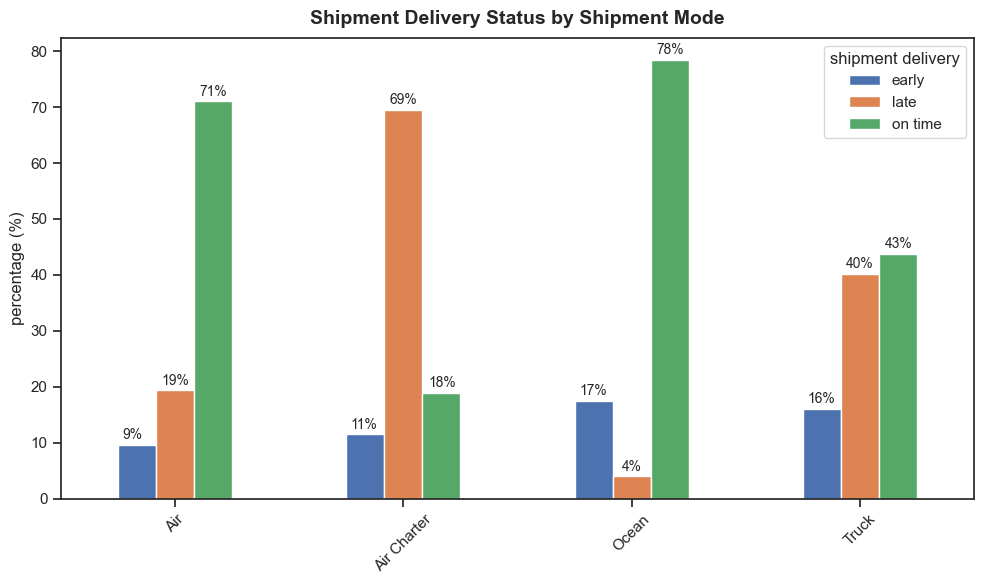

In [16]:
df_mode_prc.plot(kind = 'bar',
            figsize = (10,6),
            xlabel = '',
            ylabel = 'percentage (%)',
             )

for i, j in enumerate(df_mode_prc['early']):
    plt.text(i-0.23, j + 1,  f'{int(j)}%', fontsize = 10, ha = 'left' )
    
for i, j in enumerate(df_mode_prc['late']):
    plt.text(i, j + 1,  f'{int(j)}%', fontsize = 10, ha = 'center')

for i, j in enumerate(df_mode_prc['on time']):
    plt.text(i+0.23, j + 1,  f'{int(j)}%', fontsize = 10, ha = 'right')
    
plt.title('Shipment Delivery Status by Shipment Mode', pad = 10, fontsize = 14, fontweight = 'bold')
plt.xticks(rotation = 45 )
plt.tight_layout()

plt.show()

**Insight:**  
- Delivery reliability varies sharply by shipment mode, with **Ocean showing the strongest on-time performance (78%)** and minimal delays.  
- **Air Charter is the weakest-performing mode**, with the majority of shipments delivered late, creating both service and cost risk.  
- **Aligning shipment urgency with the most reliable modes** would improve on-time performance and reduce overall logistics costs.



-------------------------------------------------------------------------------------------------

# Do delivery times vary by shipment mode ?

### Objective
This analysis aims to examine the overall distribution of shipment modes within the dataset in order to understand their relative frequency.

### Methodology
The distribution of shipment modes was calculated using a frequency count. The results were then visualized using a pie chart to illustrate the proportion of each shipment mode.

### Data Aggregation
Shipment mode frequencies were computed as follows:

In [17]:
df_mode_4 = df_delai['shipment mode'].value_counts()

df_mode_4

shipment mode
Air            6113
Truck          2830
Air Charter     650
Ocean           371
Name: count, dtype: int64

### Visualization

A pie chart was used to represent the percentage share of each shipment mode.

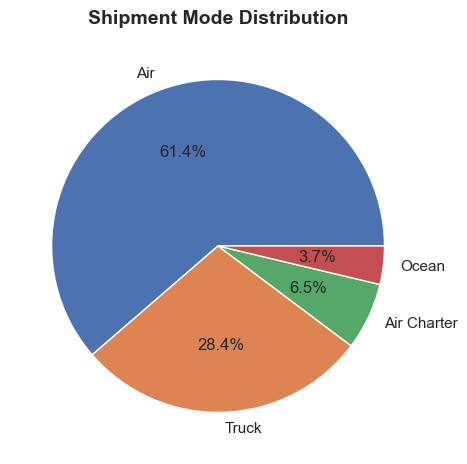

In [ ]:
df_mode_4.plot(kind = 'pie',
               xlabel = '',
               ylabel = '',
               autopct = '%1.1f%%',
               )

plt.title('Shipment Mode Distribution', pad = 10, fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()


**Insight:**  
- The shipment mix is **heavily skewed toward Air transport (61.4%)**, with Truck as the secondary mode (28.4%).  
- Limited use of **Ocean (3.7%) and Air Charter (6.5%)** suggests underutilization of potentially more cost-efficient or strategically suitable options.  
- **Rebalancing shipment modes** based on urgency and reliability could improve cost efficiency and delivery performance.



-------------------------------------------------------------------------------------------------

## Shipment Performance by Country

### Objective
This section analyzes shipment distribution and delivery performance across countries, with a focus on the most active countries in the dataset.


### Methodology
Countries were ranked based on the total number of shipments. The top 19 countries with the highest shipment volumes were selected for further analysis.

### Data Aggregation
Shipment counts by country were calculated as follows:


In [ ]:
top19_country = df_delai['country'].value_counts().head(19).to_frame()          # top 19 country

top19_country

,count
country,
South Africa,1406
Nigeria,1194
Côte d'Ivoire,1083
Uganda,779
Vietnam,688
Zambia,683
Haiti,655
Mozambique,631
Zimbabwe,538


### Visualization

A bar chart was used to display the shipment volume of the top 19 countries.

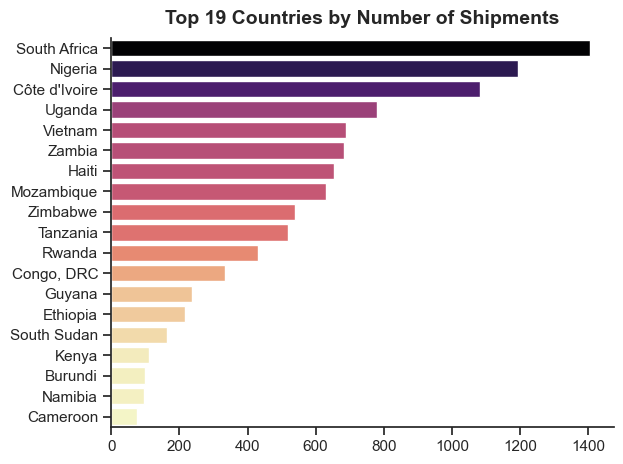

In [20]:
sns.set_theme(style = 'ticks')
sns.barplot(data = top19_country,
            x = 'count',
            y = 'country',
            hue = 'count',
            palette = 'magma_r'
            )
sns.despine()                                        # Remove the top and right spines from plot

plt.xlabel('')
plt.ylabel('')
plt.title('Top 19 Countries by Number of Shipments', pad = 10, fontsize = 14, fontweight = 'bold')

plt.legend().remove()
plt.tight_layout()
plt.show()

**Insight:**  
- Shipment volumes are **highly concentrated in a small number of countries**, with **South Africa and Nigeria** accounting for the largest share.  
- This concentration increases **operational and performance risk**, as disruptions in a few markets can disproportionately impact overall delivery outcomes.  
- **Focusing network optimization and performance initiatives on high-volume countries** would deliver the greatest efficiency and service improvements.


-----------------------------------------------------------------------------------------------

# Do delivery times vary by country ?

## Methodology

The three countries with the highest shipment volumes were selected to analyze delivery performance in greater detail.

In [ ]:
top3_country = df_delai['country'].value_counts().head(3).index         # top 3 country index

top3_country

Index(['South Africa', 'Nigeria', 'Côte d'Ivoire'], dtype='object', name='country')

In [ ]:
df_top3 = df_delai[df_delai['country'].isin(top3_country)]               

df_top3

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
5,Nigeria,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-09-28,2006-09-28,5920.42,NaN,0,on time
8,Nigeria,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-12-07,2006-12-07,See ASN-93 (ID#:1281),NaN,0,on time
12,Nigeria,EY Laboratories,Air,HRDT,HIV test,Date Not Captured,2007-01-10,2007-01-10,Invoiced Separately,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10314,Nigeria,SCMS from RDC,Air Charter,ARV,Pediatric,N/A - From RDC,2015-06-30,2015-05-15,See DN-4274 (ID#:84472),38.27,46,late
10315,Nigeria,SCMS from RDC,Air Charter,ARV,Adult,N/A - From RDC,2015-06-30,2015-05-15,26180,1341.33,46,late
10316,Nigeria,SCMS from RDC,Air Charter,ARV,Adult,N/A - From RDC,2015-06-02,2015-05-15,3410,115.11,18,late
10317,Nigeria,SCMS from RDC,Air,ARV,Adult,N/A - From RDC,2015-06-30,2015-06-22,See DN-4282 (ID#:83919),24.69,8,late


### Data Aggregation

A pivot table was created to summarize delivery outcomes by country.

In [23]:
df_top3_pvt = df_top3.pivot_table(index = 'country',
                    columns = 'shipment delivery',
                    aggfunc = 'size').sort_values(by = 'on time', ascending = False)

df_top3_pvt['total'] = df_top3_pvt.sum(axis=1)

df_top3_pvt

shipment delivery,early,late,on time,total
country,,,,
South Africa,115,278,1013,1406
Côte d'Ivoire,134,349,600,1083
Nigeria,142,557,495,1194


In [24]:
for col in ['early', 'on time', 'late']:
    df_top3_pvt[col] = (df_top3_pvt[col] / df_top3_pvt['total']) * 100

df_top3_pvt.drop(columns = 'total', inplace = True)
df_top3_pvt

shipment delivery,early,late,on time
country,,,
South Africa,8.179232,19.772404,72.048364
Côte d'Ivoire,12.373038,32.225300,55.401662
Nigeria,11.892797,46.649916,41.457286


### Visualization

Pie charts were used to illustrate the percentage distribution of delivery outcomes for each of the top three countries.

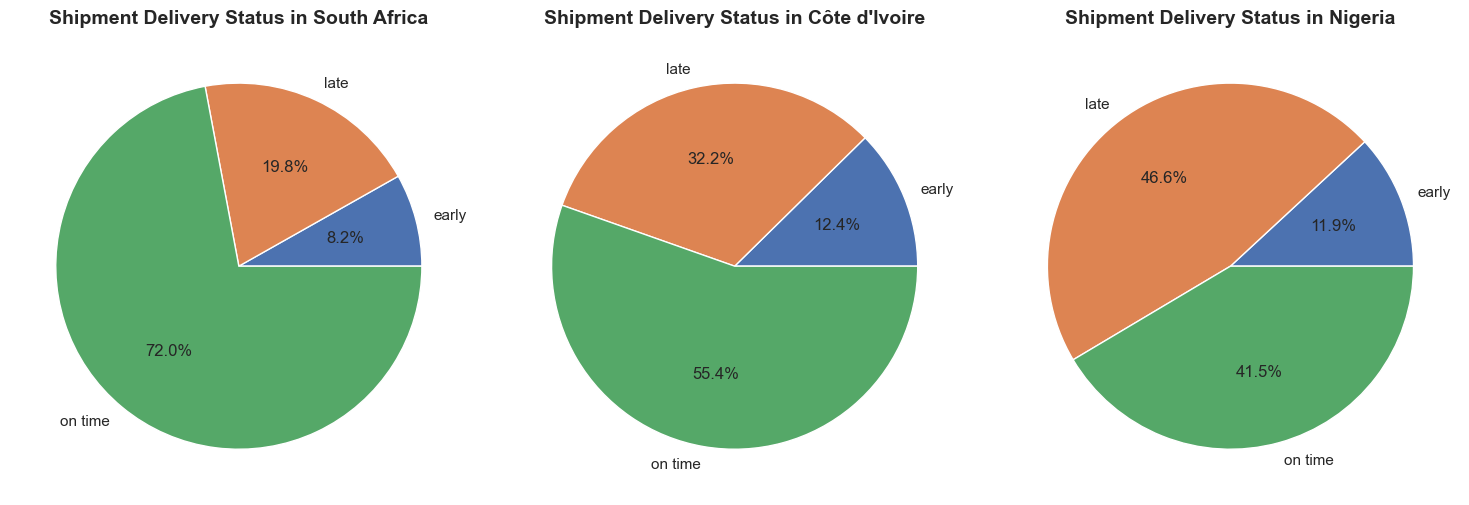

In [25]:
fig , ax = plt.subplots(1, 3, figsize = (15,5))

for i, country in enumerate(df_top3_pvt.index):
    df_top3_pvt.loc[country].plot(kind = 'pie',
                                  ax = ax[i],
                                  xlabel = '',
                                  ylabel = '',
                                  autopct = '%1.1f%%',
                                  )
    ax[i].set_title(f'Shipment Delivery Status in {country}', pad = 10, fontsize = 14, fontweight = 'bold')
    ax[i].legend().remove()
plt.tight_layout()
plt.show()
    
    

**Insight:**  
- Delivery reliability differs materially by country, with **South Africa performing strongly**, **Côte d’Ivoire at a moderate level**, and **Nigeria experiencing the highest share of late shipments**.  
- Higher delay rates, particularly in Nigeria, increase the risk of **service disruption, cost escalation, and customer dissatisfaction** in key markets.  
- **Prioritizing targeted operational improvements in Nigeria** and replicating best practices from South Africa could significantly improve overall regional performance.



-------------------------------------------------------------------------------------------------

# Does shipment delivery status affect freight costs ?
### Objective
This analysis examines the relationship between **shipment delivery status** and **freight cost**, with a focus on comparing median freight costs for late and on-time shipments across shipment modes.


## Data Preparation


In [26]:
df_C = df_delai.copy()
df_C

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6,early
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


In [ ]:
df_C = df_C[df_C['shipment delivery'].isin(['on time', 'late'])]     # filtring data

df_C

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10318,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),869.66,16,late
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


### Data Cleaning
To ensure accurate cost analysis, the dataset was filtered and cleaned as follows:
- Removed missing freight cost values
- Converted freight cost values to numeric format
- Retained only shipments with delivery status classified as *on time* or *late*

In [28]:
df_C['freight cost (usd)'].value_counts()

freight cost (usd)
Freight Included in Commodity Cost    1390
Invoiced Separately                    224
9736.1                                  33
See DN-304 (ID#:10589)                  16
6147.18                                 16
                                      ... 
See DN-4265 (ID#:83335)                  1
See DN-4274 (ID#:84472)                  1
26180                                    1
3410                                     1
See DN-4282 (ID#:83919)                  1
Name: count, Length: 5984, dtype: int64

In [ ]:
df_C = df_C.copy()

df_C["freight cost (usd)"] = pd.to_numeric(df_C["freight cost (usd)"] , errors="coerce")           #converting to num (text = Nan)

df_C["freight cost (usd)"]

0          780.34
1         4521.50
2         1653.78
3        16007.06
4        45450.08
           ...   
10318         NaN
10319         NaN
10321         NaN
10322         NaN
10323         NaN
Name: freight cost (usd), Length: 9138, dtype: float64

In [30]:
df_C = df_C.dropna(subset=["freight cost (usd)"])

df_C.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5454 entries, 0 to 10316
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   country                    5454 non-null   object        
 1   vendor                     5454 non-null   object        
 2   shipment mode              5245 non-null   object        
 3   product group              5454 non-null   object        
 4   sub classification         5454 non-null   object        
 5   po sent to vendor date     5454 non-null   object        
 6   scheduled delivery date    5454 non-null   datetime64[ns]
 7   delivered to client date   5454 non-null   datetime64[ns]
 8   freight cost (usd)         5454 non-null   float64       
 9   line item insurance (usd)  5266 non-null   float64       
 10  delay                      5454 non-null   int64         
 11  shipment delivery          5454 non-null   object        
dtypes: datetim

### Methodology

Median freight costs were calculated for each delivery status to reduce the influence of extreme values.

In [31]:
df_C_plot = df_C.groupby('shipment delivery')['freight cost (usd)'].median().to_frame()

df_C_plot

,freight cost (usd)
shipment delivery,
late,7363.74
on time,4851.00


### Visualization

A bar chart was used to compare median freight costs between late and on-time shipments.

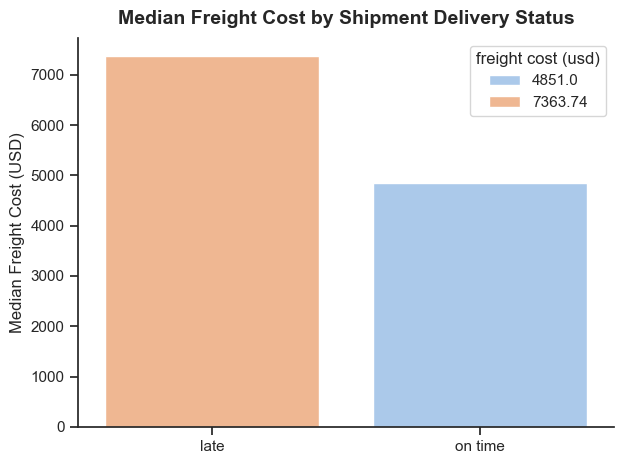

In [32]:
sns.set_theme(style = 'ticks')
sns.barplot(data = df_C_plot,
            x = 'shipment delivery',
            y = 'freight cost (usd)',
            palette = 'pastel',
            hue = 'freight cost (usd)',
            )
sns.despine()

plt.title('Median Freight Cost by Shipment Delivery Status', pad = 10, fontsize = 14, fontweight = 'bold')
plt.xlabel('')
plt.ylabel('Median Freight Cost (USD)')

plt.tight_layout()
plt.show()

**Insight:**  
- Late shipments have a **substantially higher median freight cost** (≈ USD 7.4K) compared to **on-time shipments** (≈ USD 4.9K).  
- Delivery delays are directly associated with a **~50% increase in freight spend**, driven by expedites, re-routing, and exception handling.  
- Reducing late deliveries represents a **high-impact lever** to lower overall logistics costs while improving service performance.




--------------------------------------------------------------------------

## Is there a trade-off between delivery time and cost ?

### Methodology

The dataset was split by delivery status, and median freight costs were calculated for each shipment mode.

In [ ]:
df_C_late = df_C[df_C['shipment delivery'] == 'late']             # late data

df_C_on_time = df_C[df_C['shipment delivery'] == 'on time']       # on time data

### Visualization

Two side-by-side bar charts were used to compare median freight costs by shipment mode for late and on-time deliveries.

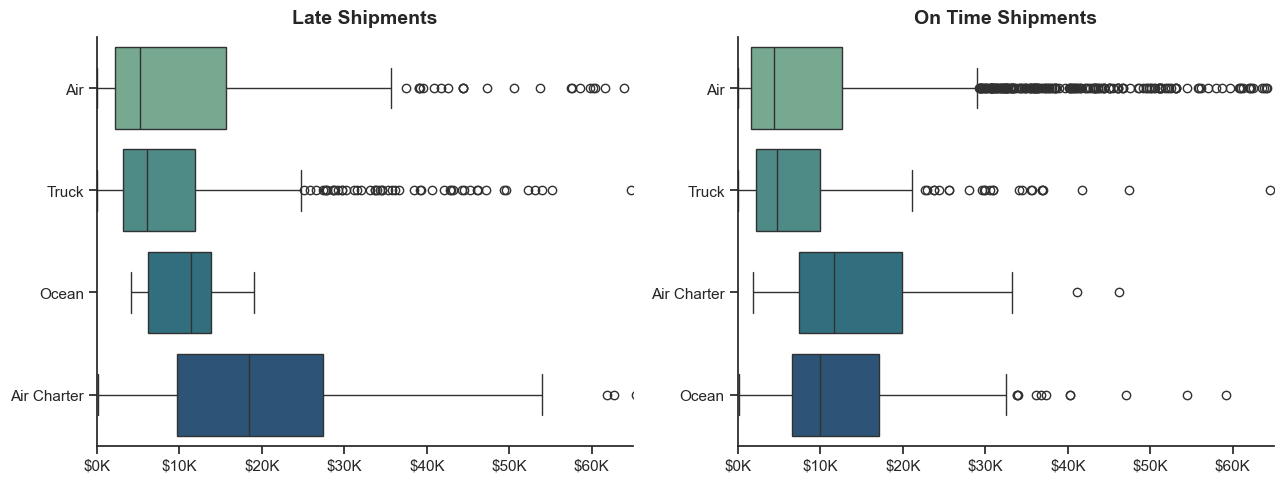

In [34]:
fig , ax = plt.subplots(1,2, figsize=(13,5))

sns.set_theme(style = 'ticks')
sns.boxplot(data = df_C_late,
            x = 'freight cost (usd)',
            y = 'shipment mode',
            ax = ax[0],
            palette='crest',
            hue= 'shipment mode',
            legend=False,
            )
ax[0].set_title('Late Shipments', fontsize=14, fontweight='bold', pad=10)
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
ax[0].set_xlim(0, 65000)

sns.boxplot(data = df_C_on_time,
            x = 'freight cost (usd)',
            y = 'shipment mode',
            ax = ax[1],
            hue='shipment mode',
            palette='crest',
            legend=False,
            )
ax[1].set_title('On Time Shipments', fontsize=14, fontweight='bold', pad=10)
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
ax[1].set_xlim(0, 65000)

sns.despine()

plt.tight_layout()

plt.show()

**Insight:**  
- Late shipments exhibit **higher median freight costs and significantly greater cost variability** across all shipment modes.  
- **Air Charter shows the highest cost exposure and widest spread**, indicating substantial financial risk when delays occur.  
- Improving delivery reliability in **high-cost modes** would generate the largest cost savings and reduce overall freight spend volatility.




--------------------------------------------------------------------------------------------------------

# Which product groups are most at risk of delays ?

### Objective
This section analyzes shipment delivery performance across the **top vendors** and **top product groups** based on shipment volume, with a focus on delivery status distribution.

### Methodology

The three most frequently shipped product groups were selected. Shipment delivery outcomes were aggregated and converted into percentages to enable normalized comparison.

### Data Aggregation

In [ ]:
prod_i = df_delai['product group'].value_counts().head(3).index             # Top 3 product groups

In [36]:
df_prod_top3 = df_delai[df_delai['product group'].isin(prod_i)]                           # Filter top 3 product groups

df_prod_top3_pvt = df_prod_top3.pivot_table(index='product group',
                     columns = 'shipment delivery',
                     aggfunc = 'size',
                     fill_value = 0,
                     )

df_prod_top3_pvt['total'] = df_prod_top3_pvt.sum(axis=1)                                   # Total shipments per product group

df_prod_top3_pvt

shipment delivery,early,late,on time,total
product group,,,,
ANTM,0,1,21,22
ARV,1073,2707,4770,8550
HRDT,113,105,1510,1728


### Percentage Calculation

In [37]:
df_prod_top3_prct = df_prod_top3_pvt.iloc[:].div(df_prod_top3_pvt['total'] / 100, axis = 0)           # Calculate percentages

df_prod_top3_prct.drop(columns='total', inplace=True)                                                 # drop total column for percentage table

df_prod_top3_prct

shipment delivery,early,late,on time
product group,,,
ANTM,0.000000,4.545455,95.454545
ARV,12.549708,31.660819,55.789474
HRDT,6.539352,6.076389,87.384259


### Visualization

Pie charts were used to display the percentage distribution of delivery outcomes for each top product group.

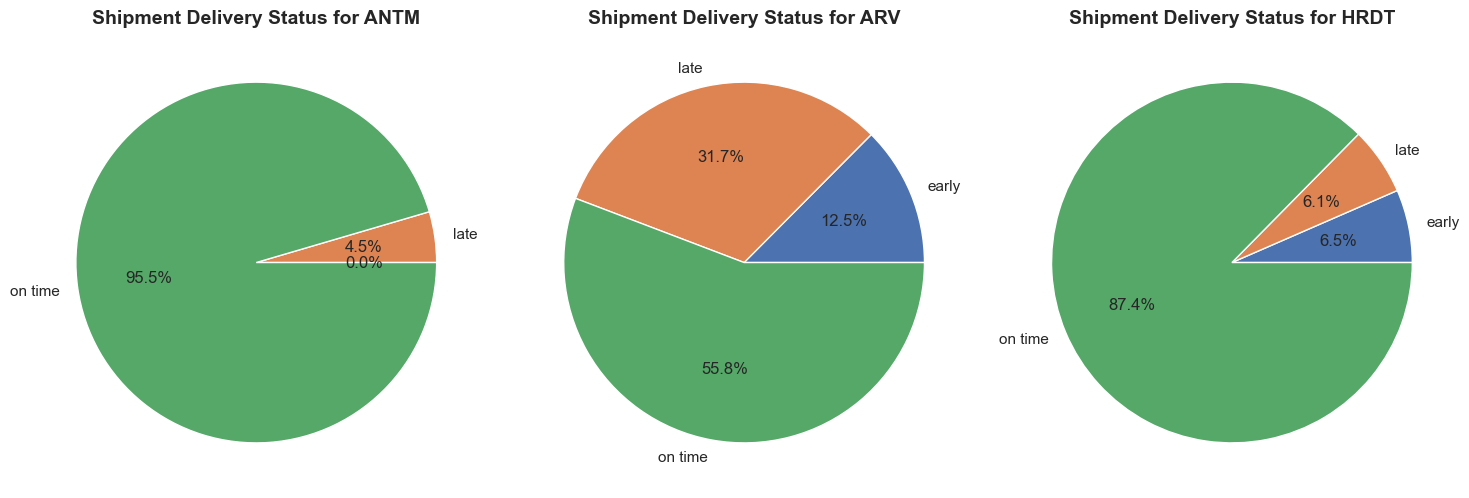

In [38]:
fig , ax = plt.subplots(1, 3, figsize = (15,5))

for i, col in enumerate(df_prod_top3_prct.index):
  df_prod_top3_prct.loc[col].plot(kind = 'pie',
                         ax = ax[i],
                         xlabel = '',
                         ylabel = '',
                         autopct = '%1.1f%%',
                         )
  ax[i].set_title(f'Shipment Delivery Status for {col}', pad = 10, fontsize = 14, fontweight = 'bold')
  ax[i].legend().remove()
plt.tight_layout()
plt.show()
                       

**Insight:**  
- Delivery performance varies significantly by product, with **ANTM and HRDT showing high reliability**, while **ARV has a substantially higher proportion of late shipments**.  
- Delays in ARV increase the risk of **service disruptions, higher freight costs, and reduced service-level performance**.  
- **Targeted corrective actions for ARV**, combined with replication of best practices from high-performing products, could materially improve overall delivery consistency.




---------------------------------------------------------------------------------

# Which vendors are the most reliable ?

### Methodology
The top seven vendors were identified based on the total number of shipments. Shipment delivery outcomes (early, late, on time) were then aggregated for each vendor using a pivot table.


### Data Aggregation

In [40]:
vd_i = df_delai['vendor'].value_counts().head(7).index         # Top 7 vendors

vd_i

Index(['SCMS from RDC', 'Orgenics, Ltd', 'S. BUYS WHOLESALER',
       'Aurobindo Pharma Limited', 'Trinity Biotech, Plc',
       'ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV)', 'PHARMACY DIRECT'],
      dtype='object', name='vendor')

In [41]:
df_vd_to7 = df_delai[df_delai['vendor'].isin(vd_i)]

df_vd_top7_pvt = df_vd_to7.pivot_table(index='vendor',
                                          columns = 'shipment delivery',
                                          aggfunc = 'size',
                                          fill_value = 0,
                        )


df_vd_top7_pvt

shipment delivery,early,late,on time
vendor,,,
ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),4,2,341
Aurobindo Pharma Limited,94,22,552
"Orgenics, Ltd",98,64,592
PHARMACY DIRECT,0,0,326
S. BUYS WHOLESALER,11,240,464
SCMS from RDC,927,2409,2068
"Trinity Biotech, Plc",1,2,353


### Visualization

A horizontal bar chart was used to compare delivery outcomes across the top seven vendors.

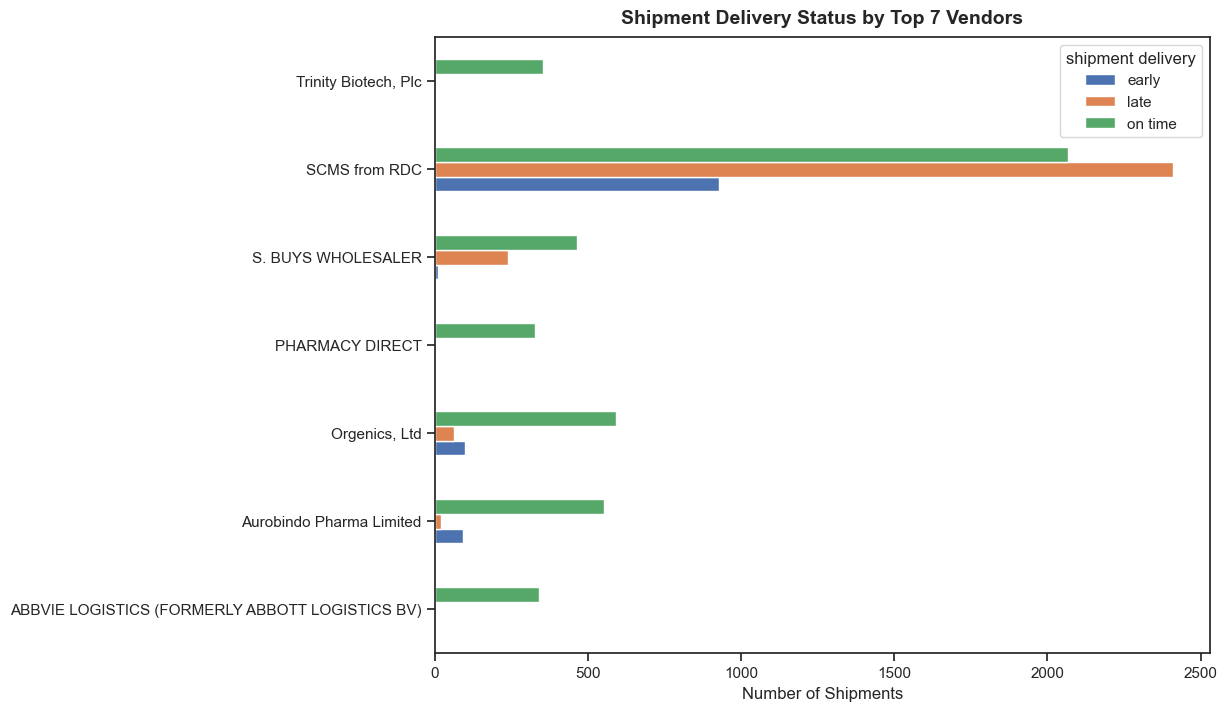

In [ ]:
df_vd_top7_pvt.plot(kind = 'barh',
            figsize = (10,8),
            xlabel = '',
            ylabel = '',
            legend = True,
             )

plt.title('Shipment Delivery Status by Top 7 Vendors', pad = 10, fontsize = 14, fontweight = 'bold')
plt.xlabel('Number of Shipments')

plt.show()

**Insight:**  
- Shipment volume and delivery performance are **highly concentrated with SCMS from RDC**, which shows both the largest volume and a **notably high number of late deliveries**, creating outsized impact on overall performance.  
- Other vendors (e.g., **Organics, Ltd, Aurobindo Pharma Limited, S. BUYS WHOLESALER**) demonstrate **more stable on-time performance**, though at lower shipment volumes.  
- **Focusing performance improvement efforts on SCMS from RDC** would yield the greatest immediate benefit, while leveraging best practices from smaller, more reliable vendors could improve consistency across the vendor base.



---

# Final Conclusions & Business Recommendations

## Project Summary
This project analyzed supply chain delivery performance using shipment-level data.  
The objective was to evaluate delivery reliability, identify the main drivers of delays, assess cost impacts, and highlight operational risks across shipment modes, countries, vendors, and product groups.

The analysis addressed the following key business questions:
- Are shipments often delayed?
- Which shipment modes cause the longest delays?
- Do delivery times vary by country?
- Do delayed shipments cost more?
- Is there a trade-off between delivery time and cost?
- Which product groups are most at risk of delays?
- Which vendors are the most reliable?

---

## Key Findings

- A significant proportion of shipments experience delivery delays, indicating recurring reliability issues.
- Shipment mode has a strong impact on delivery performance, with slower modes generally associated with longer delays.
- Delivery times vary considerably by country, suggesting regional differences in logistics efficiency.
- Delayed shipments tend to incur higher freight costs, increasing overall operational expenses.
- There is a clear trade-off between delivery speed and cost, where faster shipment modes reduce delays but increase transportation costs.
- Certain product groups are more exposed to delivery delays, making them higher risk from a supply chain perspective.
- Vendor performance is uneven, with some vendors consistently demonstrating higher reliability than others.

---

## Business Recommendations

- Prioritize reliable shipment modes and vendors for time-sensitive or high-value products.
- Use data-driven performance metrics to monitor vendors and address recurring delay patterns.
- Optimize shipment mode selection by balancing delivery urgency with cost constraints.
- Strengthen monitoring and contingency planning for product groups with high delay exposure.
- Leverage country-level performance insights to improve routing, supplier selection, or logistics partnerships.

---

## Final Conclusion

This analysis demonstrates how data-driven insights can be used to improve supply chain decision-making. By identifying the key drivers of delivery delays and their cost implications, organizations can enhance delivery reliability, control transportation costs, and reduce operational risks. The approach presented in this project can serve as a foundation for more advanced supply chain optimization and performance monitoring initiatives.
